In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
netflix=pd.read_csv(r"C:\Users\ROHIT MAURYA\Downloads\archive (1)\indian movies.csv")

In [3]:
netflix

,ID,Movie Name,Year,Timing(min),Rating(10),Votes,Genre,Language
0,tt0398974,Dr. Shaitan,1960,-,-,-,-,hindi
1,tt1702558,Nadir Khan,1968,-,-,-,-,urdu
2,tt0493437,Apna Sapna Money Money,2006,134 min,5.3,"1,892","Comedy, Musical, Romance",hindi
3,tt0273405,Aag Aur Sholay,1987,-,2.2,20,-,urdu
4,tt0049595,Parivar,1956,-,7.4,21,"Comedy, Drama, Family",hindi
...,...,...,...,...,...,...,...,...
50597,tt2784720,Sulagte Armaan,1984,-,-,-,Drama,hindi
50598,tt0315201,Aranya,1971,107 min,-,-,Drama,assamese
50599,tt0270221,Balayogini,1936,120 min,-,-,-,telugu
50600,tt0388697,Alajadi,1990,133 min,-,-,Drama,telugu


In [4]:
df=netflix.copy()

In [5]:
df

,ID,Movie Name,Year,Timing(min),Rating(10),Votes,Genre,Language
0,tt0398974,Dr. Shaitan,1960,-,-,-,-,hindi
1,tt1702558,Nadir Khan,1968,-,-,-,-,urdu
2,tt0493437,Apna Sapna Money Money,2006,134 min,5.3,"1,892","Comedy, Musical, Romance",hindi
3,tt0273405,Aag Aur Sholay,1987,-,2.2,20,-,urdu
4,tt0049595,Parivar,1956,-,7.4,21,"Comedy, Drama, Family",hindi
...,...,...,...,...,...,...,...,...
50597,tt2784720,Sulagte Armaan,1984,-,-,-,Drama,hindi
50598,tt0315201,Aranya,1971,107 min,-,-,Drama,assamese
50599,tt0270221,Balayogini,1936,120 min,-,-,-,telugu
50600,tt0388697,Alajadi,1990,133 min,-,-,Drama,telugu


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50602 entries, 0 to 50601
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           50602 non-null  object
 1   Movie Name   50602 non-null  object
 2   Year         49041 non-null  object
 3   Timing(min)  50602 non-null  object
 4   Rating(10)   50602 non-null  object
 5   Votes        50602 non-null  object
 6   Genre        50602 non-null  object
 7   Language     50602 non-null  object
dtypes: object(8)
memory usage: 3.1+ MB


In [7]:
df['Year'] = df['Year'].str.extract('(\d{4})')

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\ROHIT MAURYA\AppData\Local\Temp\ipykernel_22268\3546255144.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['Year'] = df['Year'].str.extract('(\d{4})')


In [8]:
df["Year"]=df["Year"].ffill()
df = df.replace("-", np.nan).ffill()

In [9]:
df['Year']=df['Year'].astype(int)
df["Rating(10)"]=df['Rating(10)'].astype(float)

In [10]:
df.dropna()
df.isnull().sum()

ID             0
Movie Name     0
Year           0
Timing(min)    2
Rating(10)     2
Votes          2
Genre          2
Language       0
dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50602 entries, 0 to 50601
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           50602 non-null  object 
 1   Movie Name   50602 non-null  object 
 2   Year         50602 non-null  int64  
 3   Timing(min)  50600 non-null  object 
 4   Rating(10)   50600 non-null  float64
 5   Votes        50600 non-null  object 
 6   Genre        50600 non-null  object 
 7   Language     50602 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 3.1+ MB


In [12]:
df.isnull().sum()

ID             0
Movie Name     0
Year           0
Timing(min)    2
Rating(10)     2
Votes          2
Genre          2
Language       0
dtype: int64

In [13]:
df["Genre"].nunique()

717

In [14]:
top10=df.sort_values("Rating(10)",ascending=False).head(10)
top10

,ID,Movie Name,Year,Timing(min),Rating(10),Votes,Genre,Language
30151,tt13223848,Marasim - Beyond Borders,2020,10 min,10.0,37,Short,oriya
31301,tt14496528,Harsukh,2021,43 min,10.0,9,"Documentary, Short",urdu
7813,tt0261073,Mohabbat Ki Jeet,1960,130 min,10.0,5,Drama,hindi
7812,tt11230970,Ilu-Ilu,2020,130 min,10.0,5,Drama,marathi
42441,tt12504298,Antak,2019,6 min,10.0,7,Short,nepali
30152,tt1378728,Mareparyant Phaashi,2009,115 min,10.0,37,"Action, Adventure, Drama",marathi
39105,tt14496528,Harsukh,2021,43 min,10.0,9,"Documentary, Short",oriya
23851,tt0270062,Waqt Se Pehle,1984,46 min,10.0,6,"Short, Comedy",hindi
30153,tt0248539,Thapadya,1973,115 min,10.0,37,"Action, Adventure, Drama",marathi
23887,tt13223848,Marasim - Beyond Borders,2020,10 min,10.0,37,Short,urdu


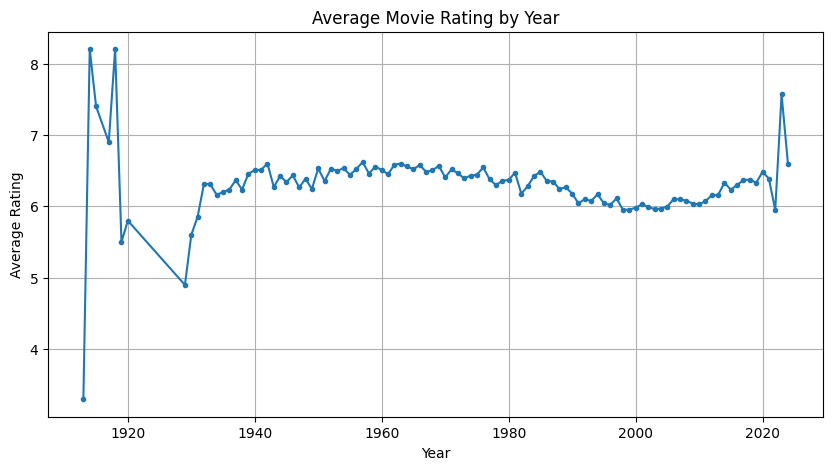

In [15]:
import matplotlib.pyplot as plt

avg_rating = df.groupby('Year')['Rating(10)'].mean()
plt.figure(figsize=(10,5))
plt.plot(avg_rating, marker='.')
plt.title('Average Movie Rating by Year')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.grid(True)
plt.show()



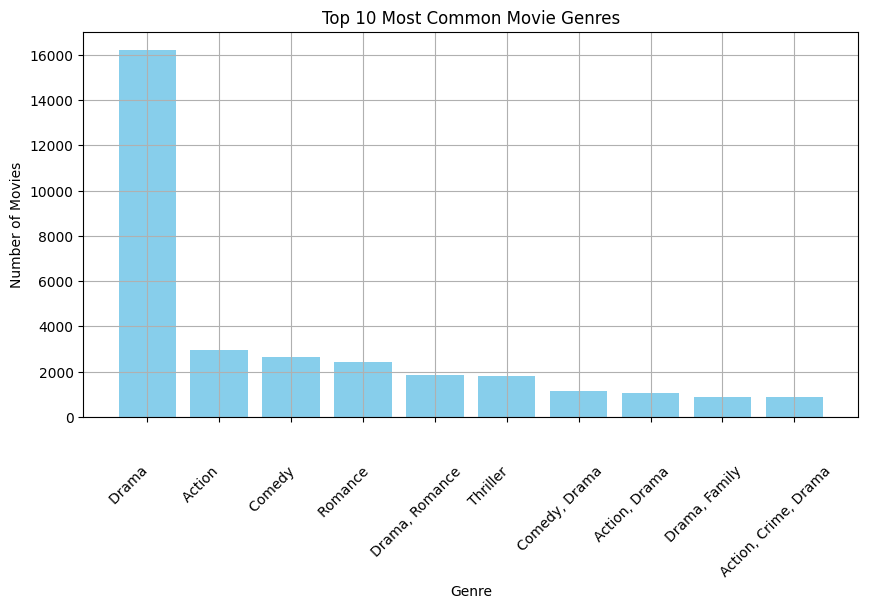

In [16]:
genre_count = df['Genre'].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(genre_count.index, genre_count.values, color='skyblue')
plt.grid(True)
plt.title('Top 10 Most Common Movie Genres')
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.show()


In [17]:
df["Language"].nunique()

19

In [18]:
df=df.bfill()
df


,ID,Movie Name,Year,Timing(min),Rating(10),Votes,Genre,Language
0,tt0398974,Dr. Shaitan,1960,134 min,5.3,"1,892","Comedy, Musical, Romance",hindi
1,tt1702558,Nadir Khan,1968,134 min,5.3,"1,892","Comedy, Musical, Romance",urdu
2,tt0493437,Apna Sapna Money Money,2006,134 min,5.3,"1,892","Comedy, Musical, Romance",hindi
3,tt0273405,Aag Aur Sholay,1987,134 min,2.2,20,"Comedy, Musical, Romance",urdu
4,tt0049595,Parivar,1956,134 min,7.4,21,"Comedy, Drama, Family",hindi
...,...,...,...,...,...,...,...,...
50597,tt2784720,Sulagte Armaan,1984,141 min,5.8,"1,201",Drama,hindi
50598,tt0315201,Aranya,1971,107 min,5.8,"1,201",Drama,assamese
50599,tt0270221,Balayogini,1936,120 min,5.8,"1,201",Drama,telugu
50600,tt0388697,Alajadi,1990,133 min,5.8,"1,201",Drama,telugu


In [19]:
df1=df.head(10000)

In [20]:
df1['features'] = (
    df1['Genre'] + ' ' + 
    df1['Language'] + ' ' + 
    df1['Rating(10)'].astype(str)
)

C:\Users\ROHIT MAURYA\AppData\Local\Temp\ipykernel_22268\2400606515.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['features'] = (


In [21]:
df1['features'] = df1['features'].fillna('')


C:\Users\ROHIT MAURYA\AppData\Local\Temp\ipykernel_22268\1449570589.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['features'] = df1['features'].fillna('')


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english')
feature_vectors = vectorizer.fit_transform(df1['features'])


In [23]:
from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity(feature_vectors)


In [33]:
def recommend(movie_name):
    if movie_name not in df['Movie Name'].values:
        return ["Movie not found."]
    
    movie_index = df[df['Movie Name'] == movie_name].index[0]
    distances = similarity[movie_index]
    movies_list = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x: x[1]
    )[1:20]  # finding 20 similar movies
    # now sorting it according to the rating
    similar_movies = pd.DataFrame({
        'Movie Name': [df.iloc[i[0]]['Movie Name'] for i in movies_list],
        'Rating': [df.iloc[i[0]]['Rating(10)'] for i in movies_list]
    })

    # highest rating first
    similar_movies = similar_movies.sort_values(by='Rating', ascending=False).head(5)

    print(f"\nTop 5 Recommended Movies (by similarity + rating) for: {movie_name}\n")
    return similar_movies
    


    

In [34]:
recommend("Parivar")


Top 5 Recommended Movies (by similarity + rating) for: Parivar



,Movie Name,Rating
13,Asar,8.9
6,Fazeeta,8.6
4,The Bankrupts,8.1
15,Boot Polish,8.0
3,Stanley Ka Dabba,7.8
